# STEP 3 (XGBoost) - Model Training
In this step, we're going to train XGBoost models for each personality trait and embedding.

In [77]:
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns   
import numpy as np     
import pickle                                                                                                  
from sklearn.model_selection import train_test_split                                                                                                         
from sklearn.metrics import f1_score    
from pipeline.smote_oversampling import SMOTEOversampler    
from pipeline.machine_learning_algorithms.xgboost import XGBoostClassifier


#### First, let's load the datasets and apply oversampling

In [78]:
with open('data/train_datasets/X_train_tfidf.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('data/train_datasets/y_train.pkl', 'rb') as f:
    y_train = pd.Series(pickle.load(f))
with open('data/test_datasets/y_test.pkl', 'rb') as f:
    y_test = pd.Series(pickle.load(f))

FileNotFoundError: [Errno 2] No such file or directory: 'data/train_datasets/X_train_tfidf.pkl'

TFIDF oversampling

In [79]:
smote = SMOTEOversampler(random_state=42)                                                              
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)  

Original dataset shape: X=(9322, 10000), y=(9322,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [80]:
def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df    

In [81]:
                                                                 
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))    

#### Now, We'll be training a model for TFIDF encodings

In [82]:
mbti_clf_tfidf = XGBoostClassifier(                                                                                              
    n_estimators=800,                                                                  
    learning_rate=0.03,                                     
    max_depth=12,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [83]:
mbti_clf_tfidf.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [84]:
mbti_clf_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.8023

              precision    recall  f1-score   support

           0       0.65      0.31      0.42       401
           1       0.82      0.95      0.88      1334

    accuracy                           0.80      1735
   macro avg       0.74      0.63      0.65      1735
weighted avg       0.78      0.80      0.78      1735


Evaluation for dimension: N_S
Accuracy: 0.8767

              precision    recall  f1-score   support

           0       0.72      0.18      0.29       240
           1       0.88      0.99      0.93      1495

    accuracy                           0.88      1735
   macro avg       0.80      0.58      0.61      1735
weighted avg       0.86      0.88      0.84      1735


Evaluation for dimension: T_F
Accuracy: 0.8086

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       939
           1       0.80      0.77      0.79       796

    accuracy                       

In [85]:
for key, value in mbti_clf_tfidf.models.items():                                                                               
    caminho = f"models/xgboost/{key}_tfidf_qwen.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/xgboost/I_E_tfidf_qwen.json
Salvo: models/xgboost/N_S_tfidf_qwen.json
Salvo: models/xgboost/T_F_tfidf_qwen.json
Salvo: models/xgboost/J_P_tfidf_qwen.json


#### Next, W2V encodings

In [ ]:
with open('data/train_datasets/X_train_w2v.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('data/test_datasets/X_test_w2v.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('data/train_datasets/y_train.pkl', 'rb') as f:
    y_train = pd.Series(pickle.load(f))
with open('data/test_datasets/y_test.pkl', 'rb') as f:
    y_test = pd.Series(pickle.load(f))
    
smote = SMOTEOversampler(random_state=42)                        

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)  

def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df    
                                                                 
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))    

Original dataset shape: X=(9322, 500), y=(9322,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
mbti_clf_w2v = XGBoostClassifier(                                                                                              
    n_estimators=800,                                                                  
    learning_rate=0.03,                                     
    max_depth=12,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [ ]:
mbti_clf_w2v.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [ ]:
mbti_clf_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7533

              precision    recall  f1-score   support

           0       0.43      0.21      0.28       401
           1       0.79      0.92      0.85      1334

    accuracy                           0.75      1735
   macro avg       0.61      0.56      0.57      1735
weighted avg       0.71      0.75      0.72      1735


Evaluation for dimension: N_S
Accuracy: 0.8622

              precision    recall  f1-score   support

           0       0.51      0.14      0.22       240
           1       0.88      0.98      0.92      1495

    accuracy                           0.86      1735
   macro avg       0.69      0.56      0.57      1735
weighted avg       0.83      0.86      0.83      1735


Evaluation for dimension: T_F
Accuracy: 0.7683

              precision    recall  f1-score   support

           0       0.80      0.77      0.78       939
           1       0.74      0.77      0.75       796

    accuracy                       

In [ ]:
for key, value in mbti_clf_w2v.models.items():                                                                               
    caminho = f"models/xgboost/{key}_w2v_qwen.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/xgboost/I_E_w2v_qwen.json
Salvo: models/xgboost/N_S_w2v_qwen.json
Salvo: models/xgboost/T_F_w2v_qwen.json
Salvo: models/xgboost/J_P_w2v_qwen.json


#### Let's train a model for the posts before the augmentation, just as a matter of comparison

In [ ]:
with open('data/train_datasets/X_train_tfidf.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('data/train_datasets/y_train.pkl', 'rb') as f:
    y_train = pd.Series(pickle.load(f))
with open('data/test_datasets/y_test.pkl', 'rb') as f:
    y_test = pd.Series(pickle.load(f))
    
X_train_original = X_train[:6940]
y_train_original = y_train[:6940]

def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df    
                                                                 
y_train_4cols = divide_mbti(y_train_original)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))    

In [ ]:
mbti_clf_posts_tfidf = XGBoostClassifier(                                                                                              
    n_estimators=800,                                                                  
    learning_rate=0.03,                                     
    max_depth=12,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [ ]:
mbti_clf_posts_tfidf = XGBoostClassifier(random_state=42)
mbti_clf_posts_w2v = XGBoostClassifier(random_state=42)

dimensoes = ['I_E', "N_S", "T_F", "J_P"]
# 2. Injetamos os pesos de cada dimensão na respectiva gaveta
for dim in dimensoes:
    # Cenário 1: Base (Sem SMOTE, Sem Aug)
    mbti_clf_posts_tfidf.models[dim].load_model(f"{caminho_pasta}/{dim}_tfidf_qwen_original_posts.json")
    mbti_clf_posts_w2v.models[dim].load_model(f"{caminho_pasta}/{dim}_w2v_qwen_original_posts.json")

In [ ]:
mbti_clf_posts_tfidf.models

{'I_E': XGBClassifier(base_score='7.462976E-1', booster='gbtree', callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, random_state=42, ...),
 'N_S': XGBClassifier(base_score='8.0975443E-1', booster='gbtree', callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopp

In [ ]:
mbti_clf_posts_tfidf.fit(X_train_original, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [ ]:
mbti_clf_posts_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.8058

              precision    recall  f1-score   support

           0       0.74      0.25      0.37       401
           1       0.81      0.97      0.89      1334

    accuracy                           0.81      1735
   macro avg       0.78      0.61      0.63      1735
weighted avg       0.79      0.81      0.77      1735


Evaluation for dimension: N_S
Accuracy: 0.8703

              precision    recall  f1-score   support

           0       0.74      0.10      0.17       240
           1       0.87      0.99      0.93      1495

    accuracy                           0.87      1735
   macro avg       0.81      0.55      0.55      1735
weighted avg       0.85      0.87      0.82      1735


Evaluation for dimension: T_F
Accuracy: 0.7994

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       939
           1       0.79      0.77      0.78       796

    accuracy                       

In [ ]:
for key, value in mbti_clf_posts_tfidf.models.items():                                                                               
    caminho = f"models/xgboost/{key}_tfidf_qwen_original_posts.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/xgboost/I_E_tfidf_qwen_original_posts.json
Salvo: models/xgboost/N_S_tfidf_qwen_original_posts.json
Salvo: models/xgboost/T_F_tfidf_qwen_original_posts.json
Salvo: models/xgboost/J_P_tfidf_qwen_original_posts.json


In [ ]:
with open('data/train_datasets/X_train_w2v.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('data/test_datasets/X_test_w2v.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('data/train_datasets/y_train.pkl', 'rb') as f:
    y_train = pd.Series(pickle.load(f))
with open('data/test_datasets/y_test.pkl', 'rb') as f:
    y_test = pd.Series(pickle.load(f))
    
X_train_original = X_train[:6940]
y_train_original = y_train[:6940]

def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df    
                                                                 
y_train_4cols = divide_mbti(y_train_original)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))    

In [ ]:
mbti_clf_posts_w2v = XGBoostClassifier(                                                                                              
    n_estimators=800,                                                                  
    learning_rate=0.03,                                     
    max_depth=12,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [ ]:
mbti_clf_posts_w2v.fit(X_train_original, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [ ]:
mbti_clf_posts_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7671

              precision    recall  f1-score   support

           0       0.48      0.11      0.18       401
           1       0.78      0.97      0.86      1334

    accuracy                           0.77      1735
   macro avg       0.63      0.54      0.52      1735
weighted avg       0.71      0.77      0.71      1735


Evaluation for dimension: N_S
Accuracy: 0.8646

              precision    recall  f1-score   support

           0       0.73      0.03      0.06       240
           1       0.87      1.00      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.80      0.52      0.50      1735
weighted avg       0.85      0.86      0.81      1735


Evaluation for dimension: T_F
Accuracy: 0.7608

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       939
           1       0.75      0.73      0.74       796

    accuracy                       

In [ ]:
for key, value in mbti_clf_posts_w2v.models.items():                                                                               
    caminho = f"models/xgboost/{key}_w2v_qwen_original_posts.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/xgboost/I_E_w2v_qwen_original_posts.json
Salvo: models/xgboost/N_S_w2v_qwen_original_posts.json
Salvo: models/xgboost/T_F_w2v_qwen_original_posts.json
Salvo: models/xgboost/J_P_w2v_qwen_original_posts.json


### Adding also a test without the SLM augmentation and only SMOTE.

In [ ]:
with open('data/train_datasets/X_train_tfidf.pkl', 'rb') as f:                                                         
    X_train = pickle.load(f)                                                                                            
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:                                                          
    X_test = pickle.load(f)                                                                                             
with open('data/train_datasets/y_train.pkl', 'rb') as f:                                                               
    y_train = pd.Series(pickle.load(f))                                                                                 
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                
    y_test = pd.Series(pickle.load(f))     

X_train_original = X_train[:6940]
y_train_original = y_train[:6940]                                        
                                                                                                                                                                                                                                                                        
smote = SMOTEOversampler(random_state=42)                                                                               
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_original, y_train_original)         

y_train_4cols = divide_mbti(y_train_balanced)                                                                           
y_test_4cols = divide_mbti(y_test)           

Original dataset shape: X=(6940, 10000), y=(6940,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [ ]:
mbti_clf_posts_oversampled_tfidf = XGBoostClassifier(                                                                                              
    n_estimators=800,                                                                  
    learning_rate=0.03,                                     
    max_depth=12,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [ ]:
mbti_clf_posts_oversampled_tfidf.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [ ]:
mbti_clf_posts_oversampled_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.8104

              precision    recall  f1-score   support

           0       0.72      0.29      0.41       401
           1       0.82      0.97      0.89      1334

    accuracy                           0.81      1735
   macro avg       0.77      0.63      0.65      1735
weighted avg       0.80      0.81      0.78      1735


Evaluation for dimension: N_S
Accuracy: 0.8738

              precision    recall  f1-score   support

           0       0.77      0.12      0.22       240
           1       0.88      0.99      0.93      1495

    accuracy                           0.87      1735
   macro avg       0.82      0.56      0.57      1735
weighted avg       0.86      0.87      0.83      1735


Evaluation for dimension: T_F
Accuracy: 0.8000

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       939
           1       0.79      0.76      0.78       796

    accuracy                       

In [ ]:
for key, value in mbti_clf_posts_oversampled_tfidf.models.items():                                                                               
    caminho = f"models/xgboost/{key}_posts_tfidf_oversampled.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")

Salvo: models/xgboost/I_E_posts_tfidf_oversampled.json
Salvo: models/xgboost/N_S_posts_tfidf_oversampled.json
Salvo: models/xgboost/T_F_posts_tfidf_oversampled.json
Salvo: models/xgboost/J_P_posts_tfidf_oversampled.json


In [ ]:
with open('data/train_datasets/X_train_w2v.pkl', 'rb') as f:                                                         
    X_train = pickle.load(f)                                                                                            
with open('data/test_datasets/X_test_w2v.pkl', 'rb') as f:                                                          
    X_test = pickle.load(f)                                                                                             
with open('data/train_datasets/y_train.pkl', 'rb') as f:                                                               
    y_train = pd.Series(pickle.load(f))                                                                                 
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                
    y_test = pd.Series(pickle.load(f))                                                                                  

X_train = X_train[:6940]
y_train = y_train[:6940]
                                                                                                        
X_train_original = X_train[:6940]
y_train_original = y_train[:6940]                                        
                                                                                                                                                                                                                                                                        
smote = SMOTEOversampler(random_state=42)                                                                               
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_original, y_train_original)         

y_train_4cols = divide_mbti(y_train_balanced)                                                                           
y_test_4cols = divide_mbti(y_test)       

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
mbti_clf_posts_oversampled_w2v = XGBoostClassifier(                                                                                              
    n_estimators=800,                                                                  
    learning_rate=0.03,                                     
    max_depth=12,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [ ]:
mbti_clf_posts_oversampled_w2v.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [ ]:
mbti_clf_posts_oversampled_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7487

              precision    recall  f1-score   support

           0       0.42      0.22      0.29       401
           1       0.80      0.91      0.85      1334

    accuracy                           0.75      1735
   macro avg       0.61      0.56      0.57      1735
weighted avg       0.71      0.75      0.72      1735


Evaluation for dimension: N_S
Accuracy: 0.8530

              precision    recall  f1-score   support

           0       0.43      0.19      0.26       240
           1       0.88      0.96      0.92      1495

    accuracy                           0.85      1735
   macro avg       0.65      0.57      0.59      1735
weighted avg       0.82      0.85      0.83      1735


Evaluation for dimension: T_F
Accuracy: 0.7643

              precision    recall  f1-score   support

           0       0.80      0.76      0.78       939
           1       0.73      0.77      0.75       796

    accuracy                       

In [ ]:
for key, value in mbti_clf_posts_oversampled_w2v.models.items():                                                                               
    caminho = f"models/xgboost/{key}_posts_w2v_oversampled.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}") 

Salvo: models/xgboost/I_E_posts_w2v_oversampled.json
Salvo: models/xgboost/N_S_posts_w2v_oversampled.json
Salvo: models/xgboost/T_F_posts_w2v_oversampled.json
Salvo: models/xgboost/J_P_posts_w2v_oversampled.json


#### Finally, the results of them 

In [ ]:
mbti_clf_posts_tfidf 

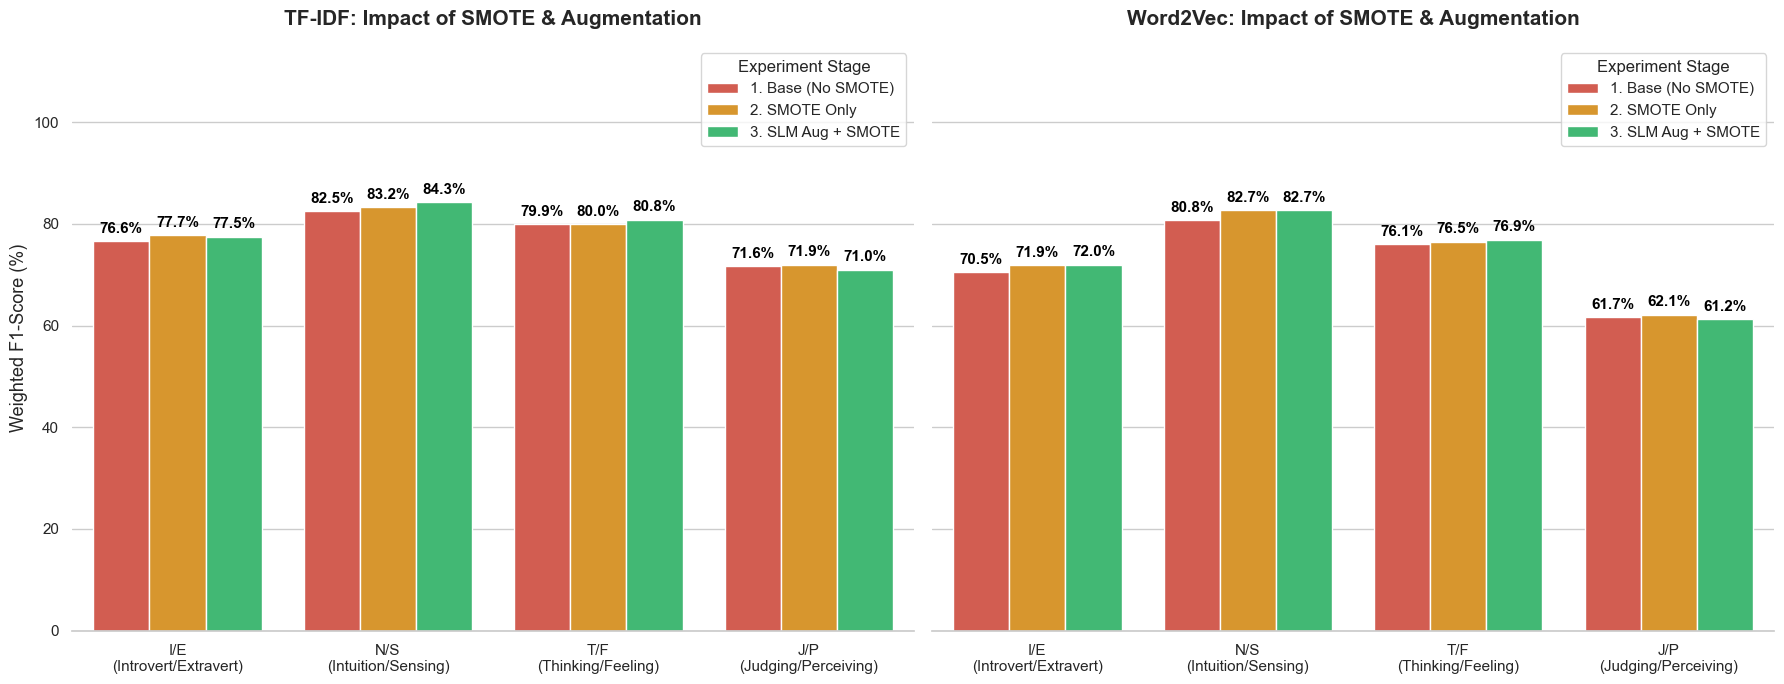

In [ ]:
import pickle                                                                                                                                
import pandas as pd                                                                                                                          
import matplotlib.pyplot as plt                                                                                                              
import seaborn as sns                                                                                                                        
from sklearn.metrics import f1_score                                                                                                         
                                                                                              
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:                                                                                 
    X_test_tfidf = pickle.load(f)                                                                                                            
with open('data/test_datasets/X_test_w2v.pkl', 'rb') as f:                                                                                   
    X_test_w2v = pickle.load(f)                                                                                                              
with open('data/test_datasets/y_test.pkl', 'rb') as f:                                                                                       
    y_test_raw = pd.Series(pickle.load(f))                                                                                                   
                                                                                                                                                
y_test_4cols = divide_mbti(y_test_raw)                                                                                    
pred_tfidf_base = mbti_clf_posts_tfidf.predict(X_test_tfidf)                                                                                 
pred_w2v_base = mbti_clf_posts_w2v.predict(X_test_w2v)                                                                                       
                                                                                                                                             
pred_tfidf_smote = mbti_clf_posts_oversampled_tfidf.predict(X_test_tfidf)                                                                    
pred_w2v_smote = mbti_clf_posts_oversampled_w2v.predict(X_test_w2v)                                                                          
                                                                                                                                            
pred_tfidf_aug = mbti_clf_tfidf.predict(X_test_tfidf)                                                                                        
pred_w2v_aug = mbti_clf_w2v.predict(X_test_w2v)                                                                                              
                                                                                                                                         
colunas = ['I_E', 'N_S', 'T_F', 'J_P']                                                                                                       
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)', 'T/F\n(Thinking/Feeling)', 'J/P\n(Judging/Perceiving)']             
                                                                                                                                                
dados = []                                                                                                                                   
for i, col in enumerate(colunas):                                                                                                            
    # -------- TF-IDF --------                                                                                                               
    f1_t_base = f1_score(y_test_4cols[col], pred_tfidf_base[col], average='weighted') * 100                                                  
    f1_t_smote = f1_score(y_test_4cols[col], pred_tfidf_smote[col], average='weighted') * 100                                                
    f1_t_aug = f1_score(y_test_4cols[col], pred_tfidf_aug[col], average='weighted') * 100                                                    
                                                                                                                                                
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_base, 'Method': '1. Base (No SMOTE)', 'Embedding': 'TF-IDF'})                       
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_smote, 'Method': '2. SMOTE Only', 'Embedding': 'TF-IDF'})                           
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_aug, 'Method': '3. SLM Aug + SMOTE', 'Embedding': 'TF-IDF'})                        
                                                                                                                                                
    # -------- Word2Vec --------                                                                                                             
    f1_w_base = f1_score(y_test_4cols[col], pred_w2v_base[col], average='weighted') * 100                                                    
    f1_w_smote = f1_score(y_test_4cols[col], pred_w2v_smote[col], average='weighted') * 100
    f1_w_aug = f1_score(y_test_4cols[col], pred_w2v_aug[col], average='weighted') * 100
    
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_base, 'Method': '1. Base (No SMOTE)', 'Embedding': 'Word2Vec'})
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_smote, 'Method': '2. SMOTE Only', 'Embedding': 'Word2Vec'})
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_aug, 'Method': '3. SLM Aug + SMOTE', 'Embedding': 'Word2Vec'})

df_plot = pd.DataFrame(dados)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_theme(style="whitegrid")

paleta = ['#e74c3c', '#f39c12', '#2ecc71']

sns.barplot(data=df_plot[df_plot['Embedding'] == 'TF-IDF'], x='Axis', y='F1 (%)', hue='Method', palette=paleta, ax=axes[0])
axes[0].set_title("TF-IDF: Impact of SMOTE & Augmentation", fontsize=15, fontweight='bold', pad=15)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Weighted F1-Score (%)", fontsize=13)
axes[0].set_xlabel("")

sns.barplot(data=df_plot[df_plot['Embedding'] == 'Word2Vec'], x='Axis', y='F1 (%)', hue='Method', palette=paleta, ax=axes[1])
axes[1].set_title("Word2Vec: Impact of SMOTE & Augmentation", fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

for ax in axes:
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.annotate(f"{altura:.1f}%", (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='baseline', fontsize=11, fontweight='bold', color='black', 
                        xytext=(0, 6), textcoords='offset points')
    ax.legend(title='Experiment Stage', fontsize='11', loc='upper right')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Finally, the results of them 